# EDA: Diabetes Risk Factors & Lifestyle Analysis
## Internship Project: Patient Behavioral Data Exploration

This notebook analyzes the **CDC BRFFS 2024** dataset to identify key correlations between lifestyle choices, healthcare access, and diabetes diagnosis. The objective is to provide actionable insights for patient health management.

**Key Objectives:**
* Evaluate the impact of physical activity on diabetes prevalence.
* Analyze the relationship between mental health and chronic illness.
* Understand how healthcare access (insurance and personal doctors) affects diagnosis status.

# Importing Libraries and Loading Data
### Data Cleaning & Label Mapping
We treat 'Pre-diabetes' as part of the 'Diabetes' risk group to focus on prevention and early intervention. Mental health values are normalized to represent 0-30 days.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# LOAD DATA

file_path = "LLCP2024.XPT"
df = pd.read_sas(file_path)


In [2]:
# SELECT VARIABLES

cols = [
    "DIABETE4",
    "SEXVAR",
    "PRIMINS2",
    "PERSDOC3",
    "EXERANY2",
    "MENTHLTH"
]

df = df[cols].copy()

In [3]:
# CLEAN INVALID VALUES
df.replace({
    "DIABETE4": {7: np.nan, 9: np.nan, 2: np.nan},
    "PRIMINS2": {77: np.nan, 99: np.nan},
    "PERSDOC3": {7: np.nan, 9: np.nan},
    "EXERANY2": {7: np.nan, 9: np.nan},
    "MENTHLTH": {77: np.nan, 99: np.nan, 88: 0}
}, inplace=True)


,DIABETE4,SEXVAR,PRIMINS2,PERSDOC3,EXERANY2,MENTHLTH
0,3.0,2.0,3.0,2.0,1.0,0.0
1,3.0,1.0,3.0,1.0,1.0,0.0
2,3.0,1.0,1.0,3.0,1.0,0.0
3,3.0,1.0,3.0,1.0,1.0,0.0
4,3.0,1.0,5.0,1.0,2.0,0.0
...,...,...,...,...,...,...
457665,3.0,1.0,3.0,1.0,1.0,2.0
457666,3.0,1.0,88.0,3.0,2.0,1.0
457667,1.0,1.0,1.0,2.0,2.0,0.0
457668,3.0,1.0,2.0,2.0,1.0,0.0


In [4]:
# FILTER DIABETES TARGET


df = df[df["DIABETE4"].isin([1, 3, 4])]

df["DIABETE4"] = df["DIABETE4"].map({
    1: "Diabetes",
    3: "Healthy",
    4: "Diabetes"
})


In [5]:
# MAP CATEGORICAL LABELS


df["SEXVAR"] = df["SEXVAR"].map({
    1: "Male",
    2: "Female"
})

df["EXERANY2"] = df["EXERANY2"].map({
    1: "Yes",
    2: "No"
})

df["PERSDOC3"] = df["PERSDOC3"].map({
    1: "Yes, only one",
    2: "More than one",
    3: "No"
})

df["PRIMINS2"] = df["PRIMINS2"].map({
    1: "Private",
    2: "Medicare",
    3: "Medigap",
    4: "Medicaid",
    5: "TRICARE",
    6: "Indian Health Service",
    7: "None",
    8: "Other"
})


# EDA

## EDA Setup
### Visualization Setup
Using a high-contrast **Neon Theme** to ensure data clarity for presentations.

In [6]:
from pypalettes import load_cmap
%config InlineBackend.figure_format = 'retina'
from qbstyles import mpl_style

neon_cmap = load_cmap('Neon')
neon_colors = np.array(neon_cmap.colors)

blue_orange_cmap = load_cmap("Blue2DarkOrange12Steps")
blue_orange_colors = np.array(blue_orange_cmap.colors)

mpl_style(dark=True)

## Helper Functions

In [7]:
# Added `data` parameter to fix function scope
def stacked_bar(data, feature, title):
    # Safely drop missing values ONLY for the specific feature being plotted
    plot_data = data.dropna(subset=[feature])

    kategori_target = ["Healthy", "Diabetes"]

    # Use plot_data instead of the global df
    crosstab = pd.crosstab(plot_data[feature], plot_data["DIABETE4"], normalize="index") * 100
    crosstab = crosstab[kategori_target]

    fig, ax = plt.subplots(figsize=(12, 6))

    crosstab.plot(
        kind="barh",
        stacked=True,
        color=['C1', 'C0'],
        width=0.6,
        ax=ax
    )

    for p in ax.patches:
        width = p.get_width()

        if width > 3:
            x = p.get_x() + width / 2
            y = p.get_y() + p.get_height() / 2

            ax.annotate(
                f"{width:.1f}%",
                (x, y),
                ha="center",
                va="center",
                color="#FFFFFF",
                fontweight="bold"
            )

    plt.title(title, fontsize=16, weight="bold", pad=20)
    plt.xlabel("Persentase (%)")
    plt.ylabel("")

    plt.legend(
        title="Status Diagnosis",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        facecolor="none",
        edgecolor="#FFFFFF"
    )

    plt.tight_layout()

    plt.show()


### Target Distribution
**Insight:** This establishes the baseline prevalence. Understanding the ratio of 'Healthy' to 'Diabetes' cases is vital for balancing future machine learning models.

/home/dio/Me/python_env/learn_pytorch/lib/python3.12/site-packages/matplotlib_inline/config.py:74: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


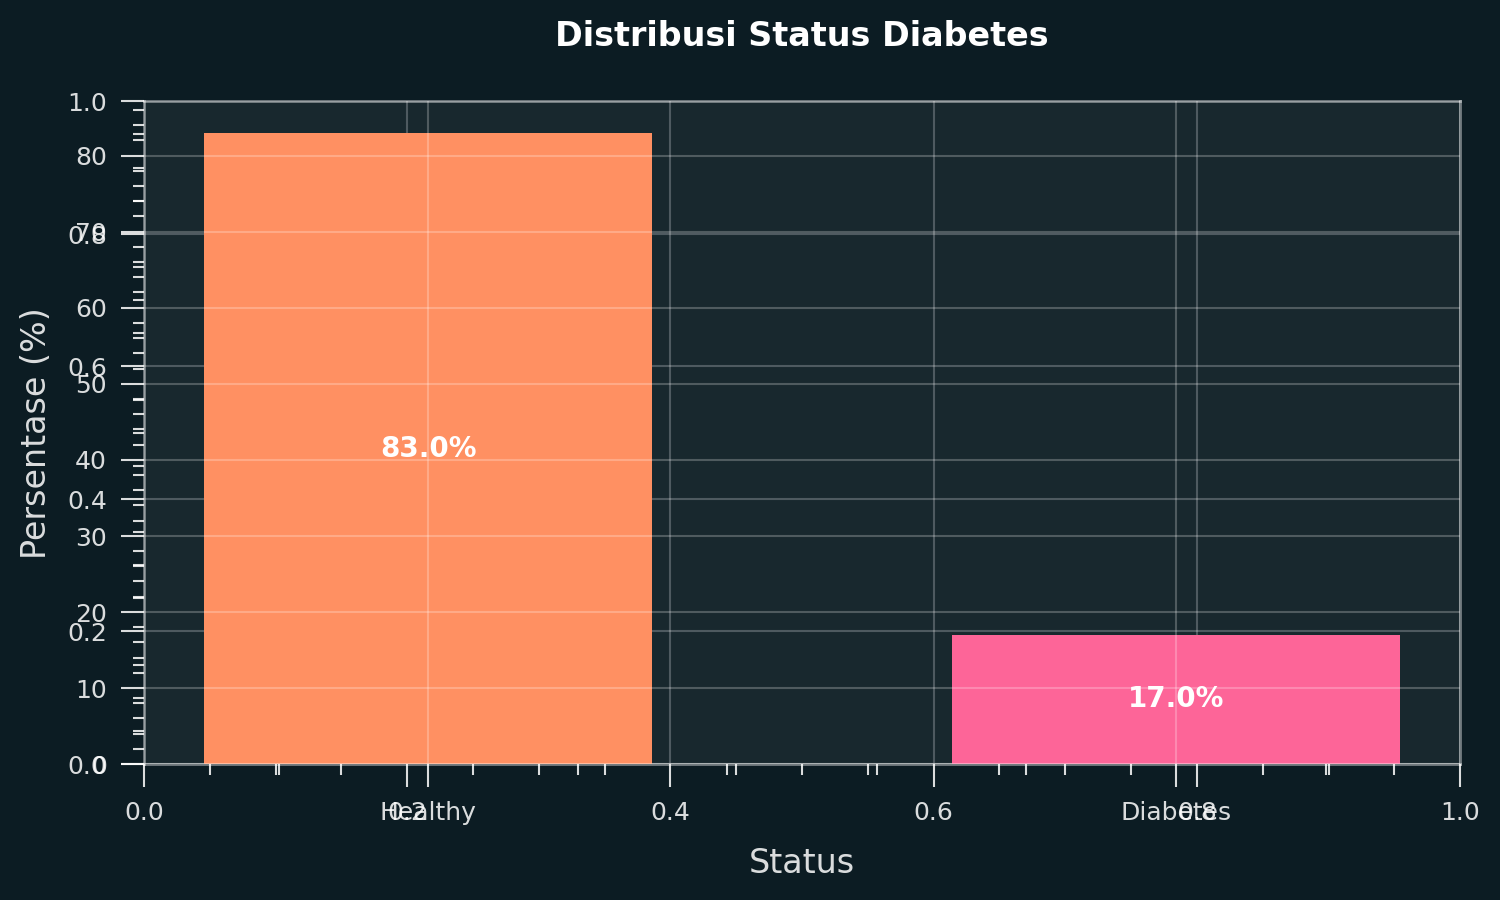

In [8]:
# 1 TARGET DISTRIBUTION


target = df["DIABETE4"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(target.index, target.values, color=neon_colors[:2], width=0.6)

for bar in bars:
    height = bar.get_height()

    ax.annotate(
        f"{height:.1f}%",
        (bar.get_x() + bar.get_width() / 2, height / 2),
        ha="center",
        va="center",
        color="#FFFFFF",
        fontweight="bold"
    )

plt.title("Distribusi Status Diabetes", weight="bold", pad=20)
plt.ylabel("Persentase (%)")
plt.xlabel("Status")

plt.tight_layout()

plt.savefig(
    "target_distribution.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Categorical Data

### 1. Sex Variable
Insight: Sex doesn't seem correlates with diabetes risk.

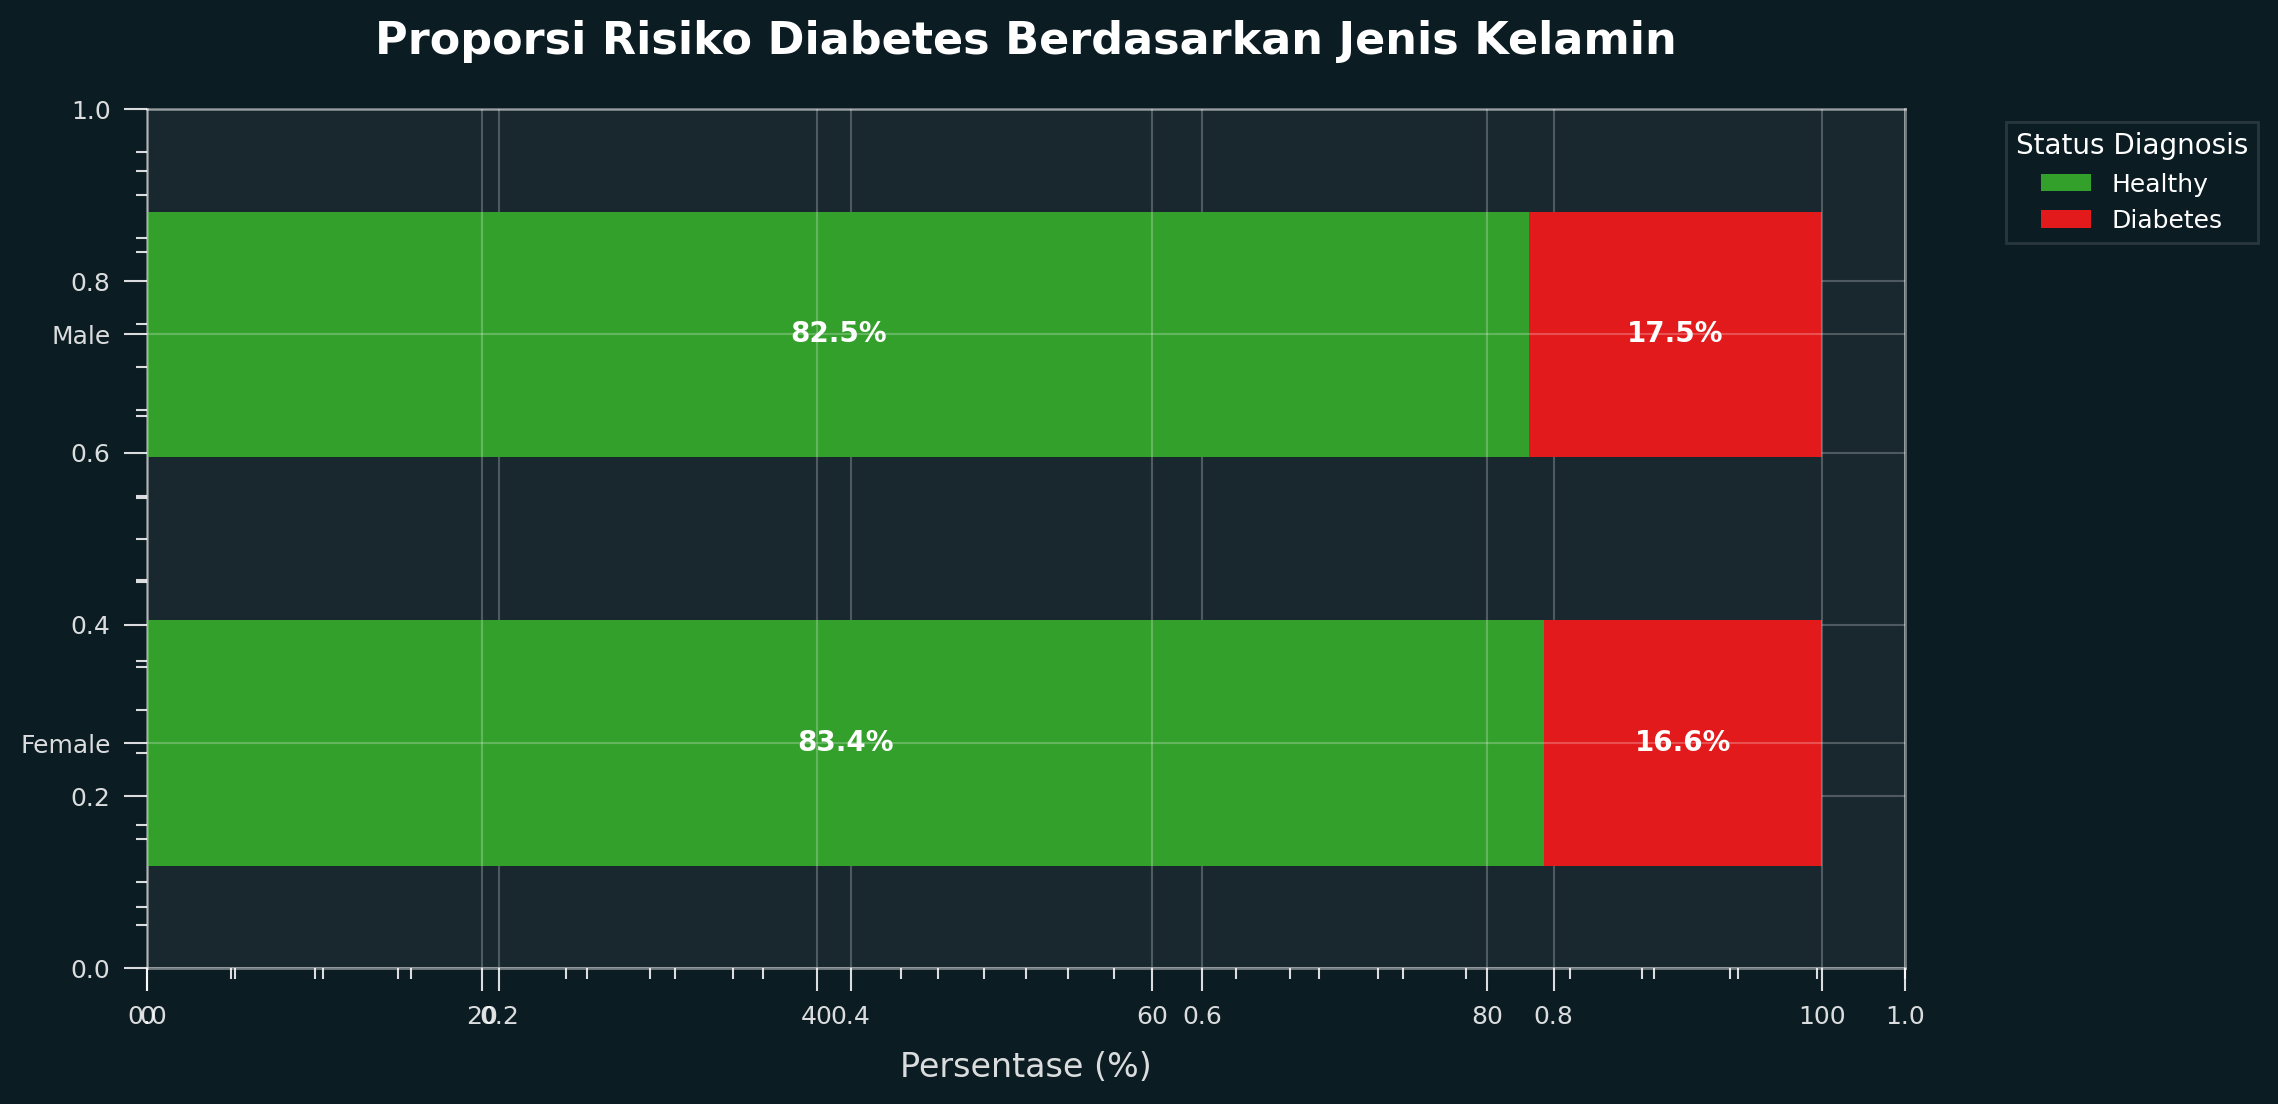

In [9]:
# 2 SEX VS DIABETES


stacked_bar(
    df,
    "SEXVAR",
    "Proporsi Risiko Diabetes Berdasarkan Jenis Kelamin"
)


### 2. Lifestyle: Physical Activity
**Insight:** Physical activity shows a strong correlation with health status. Patients who do not exercise show a significantly higher proportion of diabetes diagnosis, highlighting exercise as a key KPI for preventative health programs.

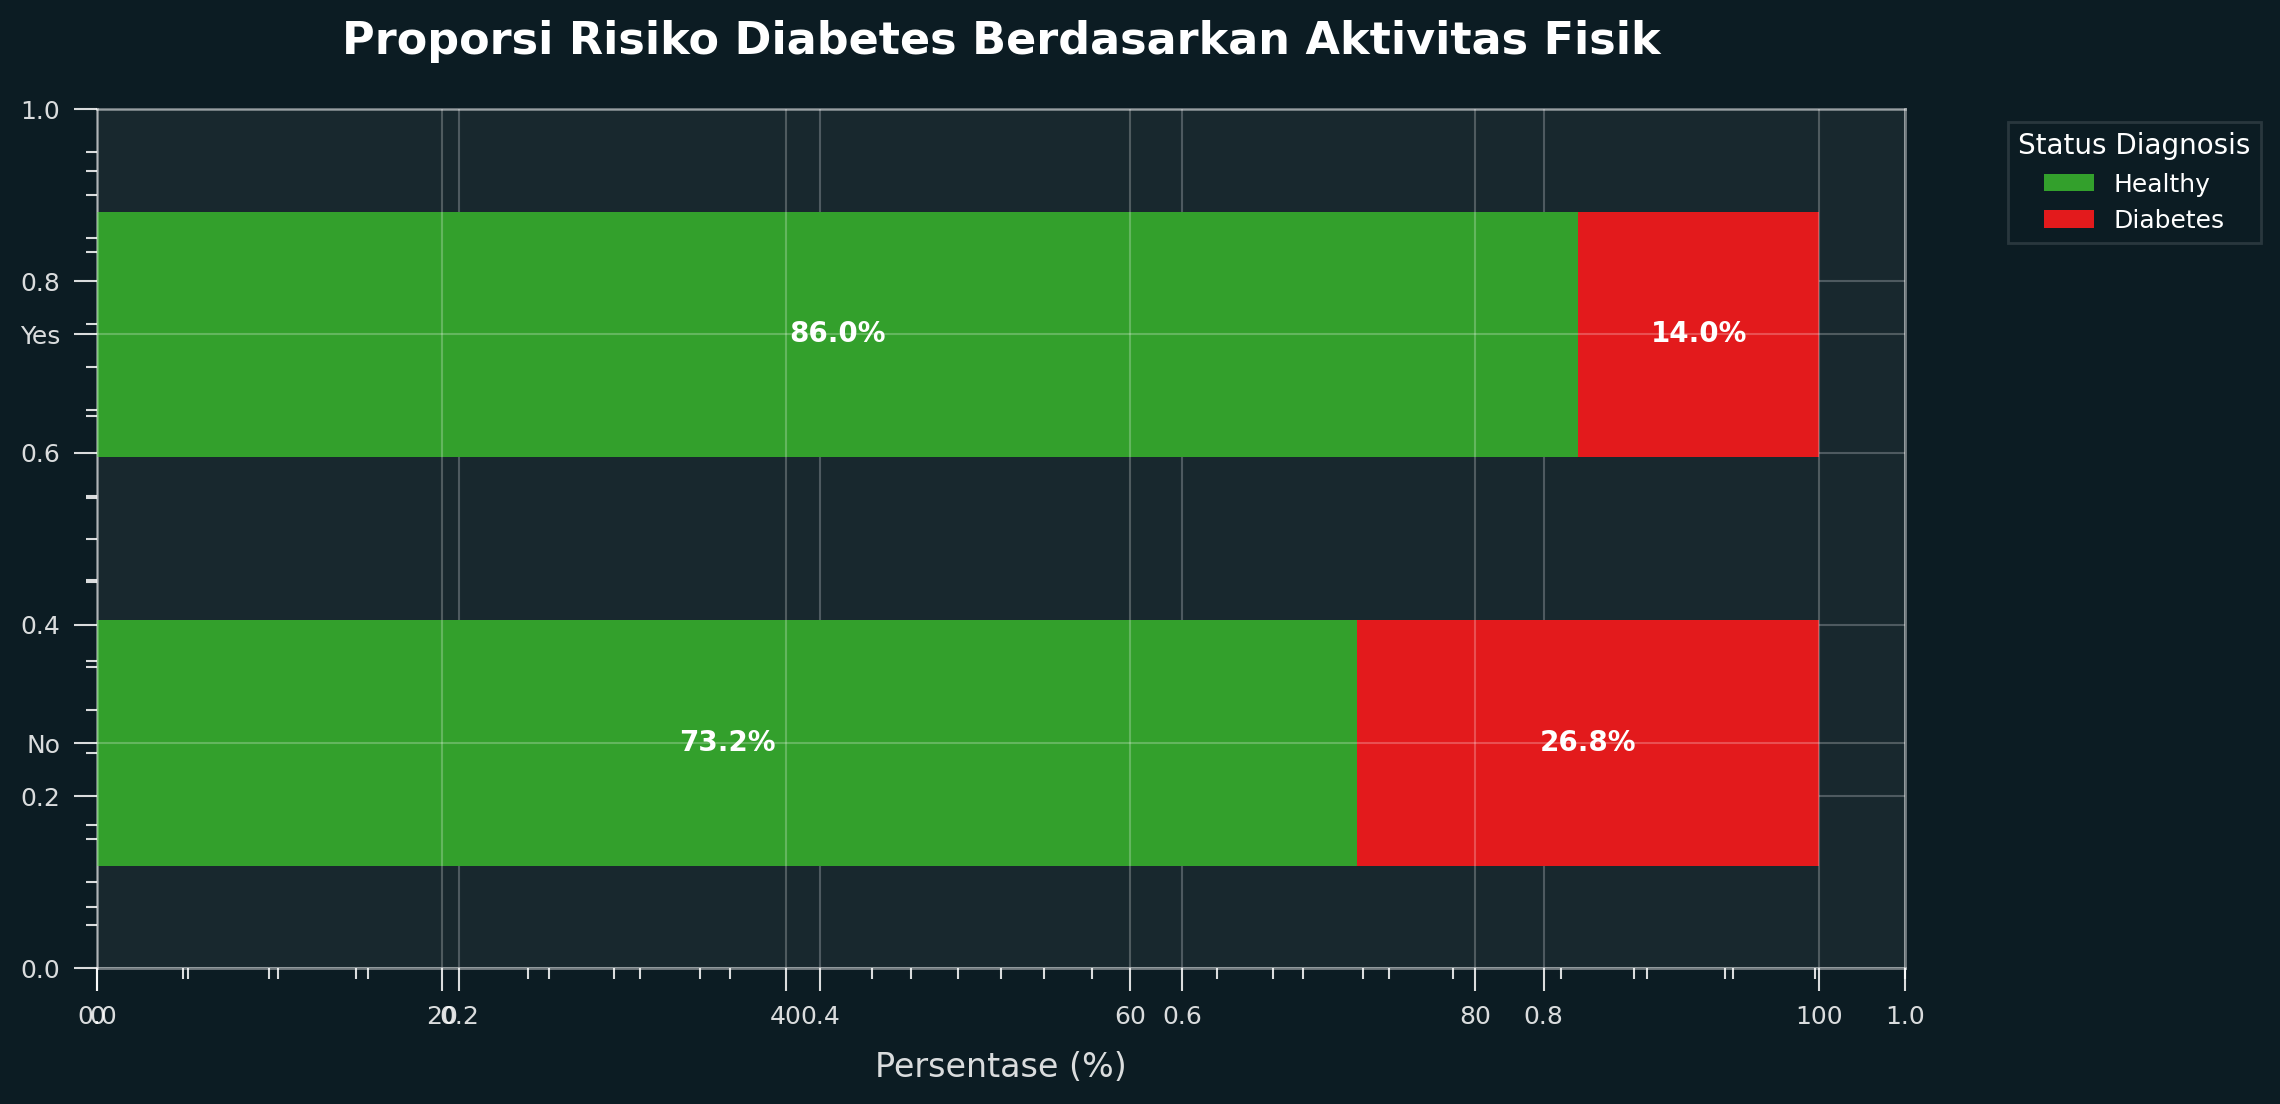

In [10]:
# 3 EXERCISE VS DIABETES


stacked_bar(
    df,
    "EXERANY2",
    "Proporsi Risiko Diabetes Berdasarkan Aktivitas Fisik"
)


### 3. Healthcare Access: Insurance & Doctors
**Insight:** Patients with multiple doctors or specific insurance types (like Medicare) often show higher diagnosis rates. This may indicate better screening access or that the condition itself necessitates more frequent clinical visits.

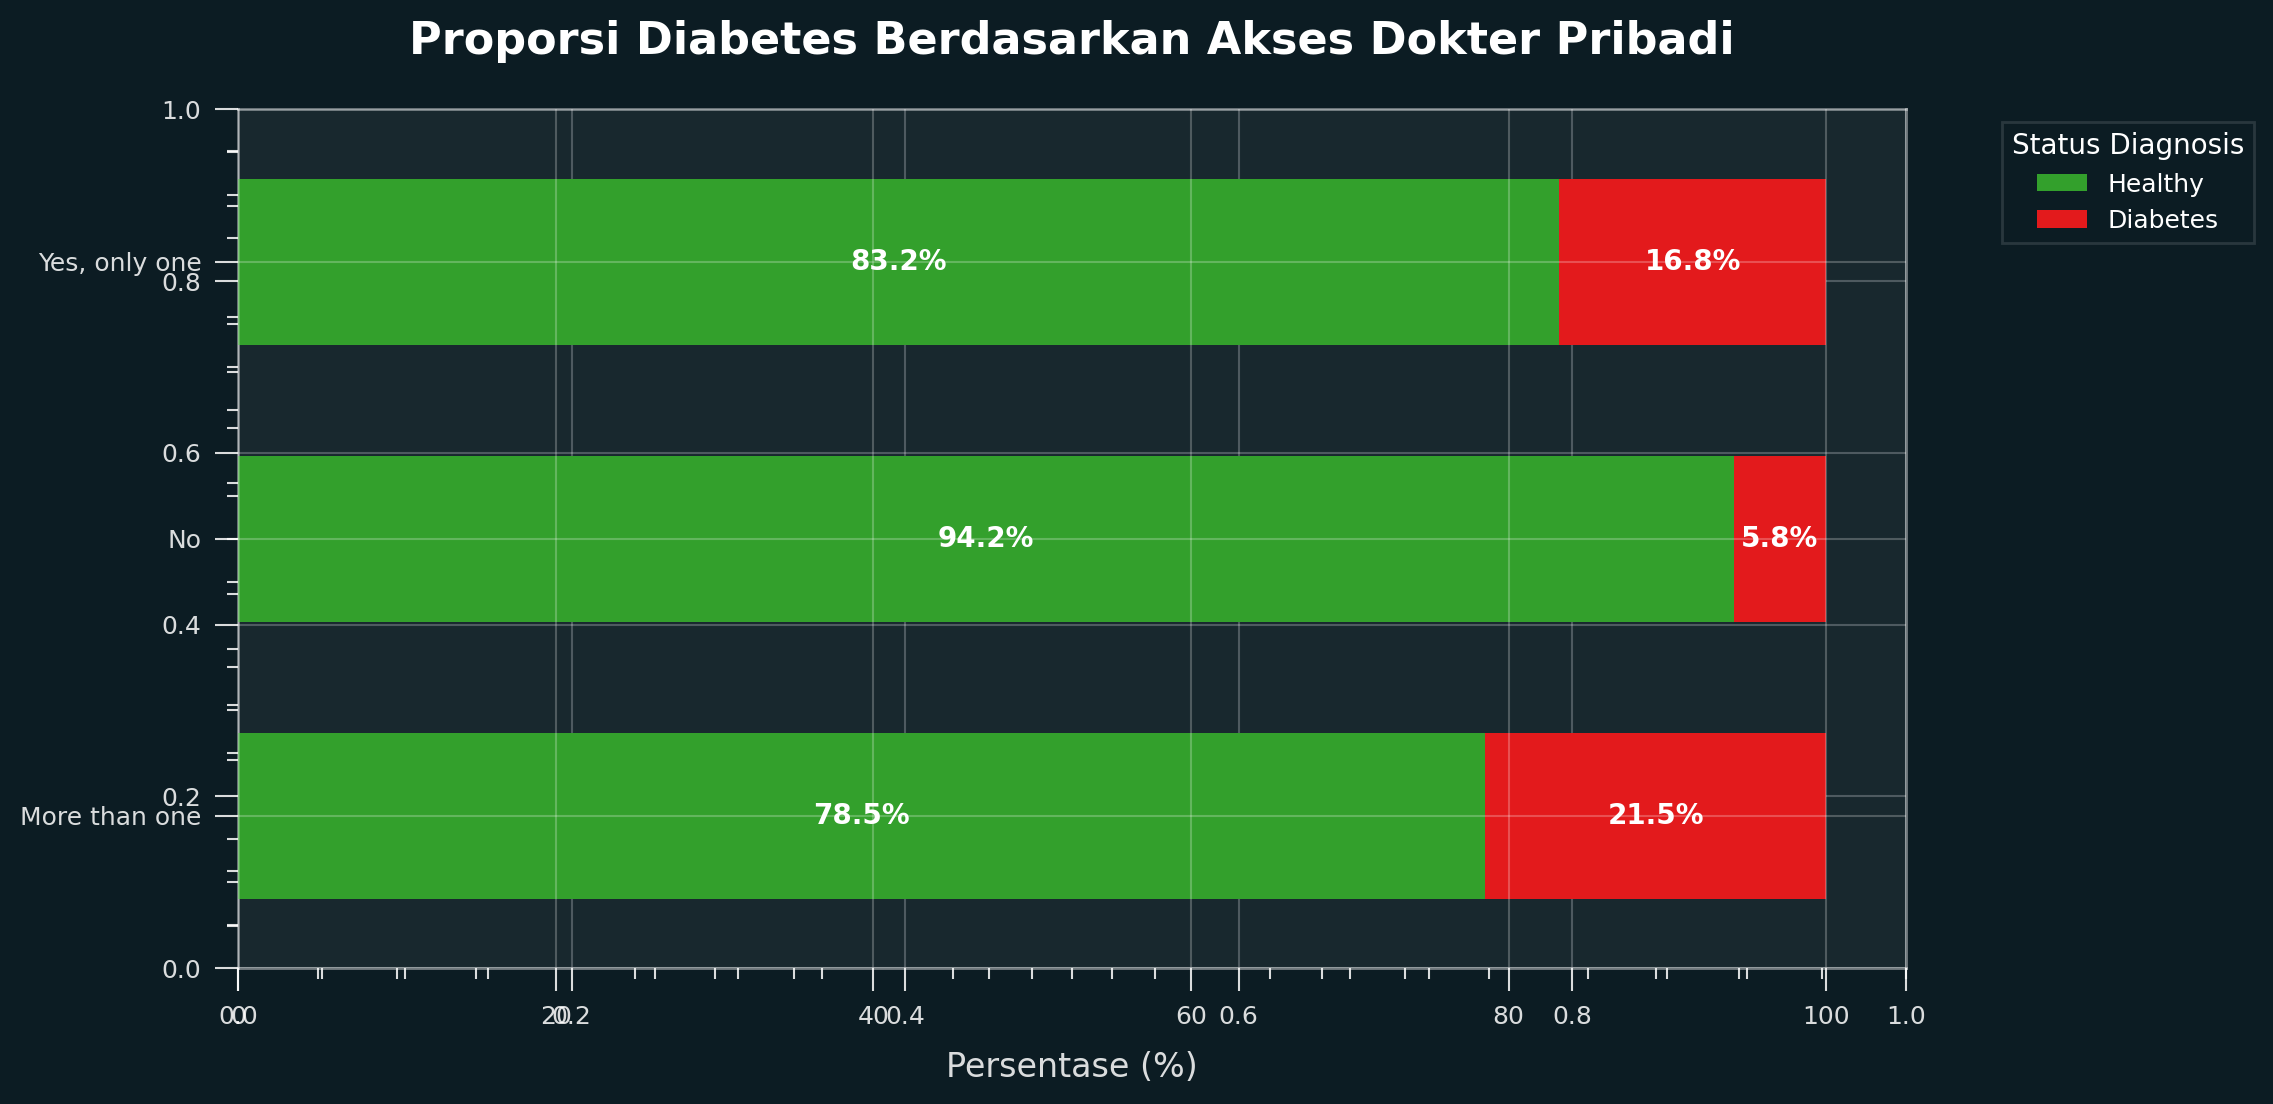

In [11]:
# 4 PERSONAL DOCTOR


stacked_bar(
    df,
    "PERSDOC3",
    "Proporsi Diabetes Berdasarkan Akses Dokter Pribadi"
)

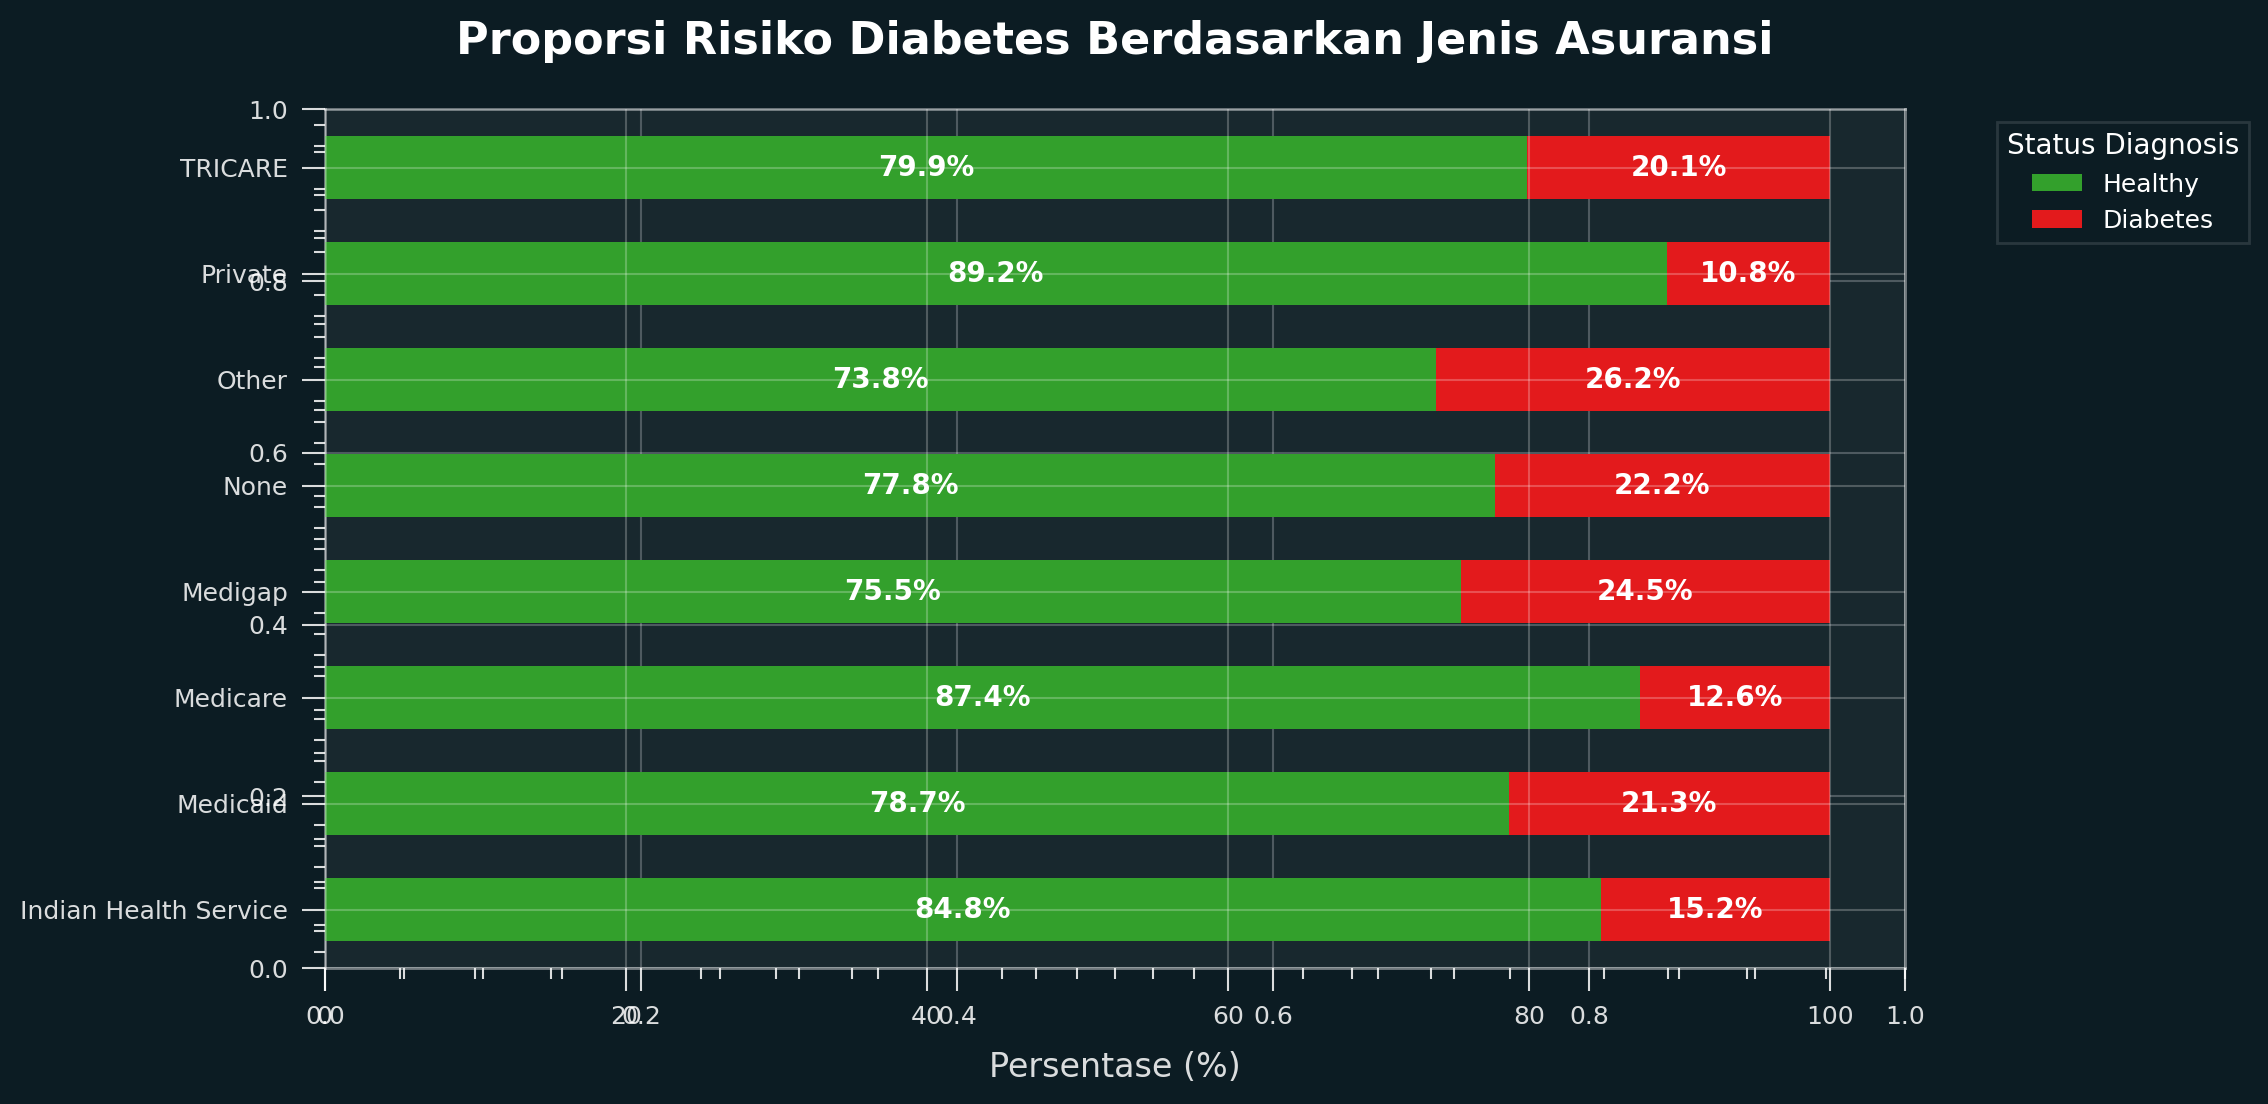

In [12]:
# 4B INSURANCE VS DIABETES


stacked_bar(
    df,
    "PRIMINS2",
    "Proporsi Risiko Diabetes Berdasarkan Jenis Asuransi"
)

## Numerical Data

### 4. Mental Health Impact
**Insight:** There is a clear trend where individuals with diabetes report a higher average number of 'poor mental health days'. This suggests that chronic disease management and mental well-being are deeply intertwined.

/tmp/ipykernel_15447/802102996.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


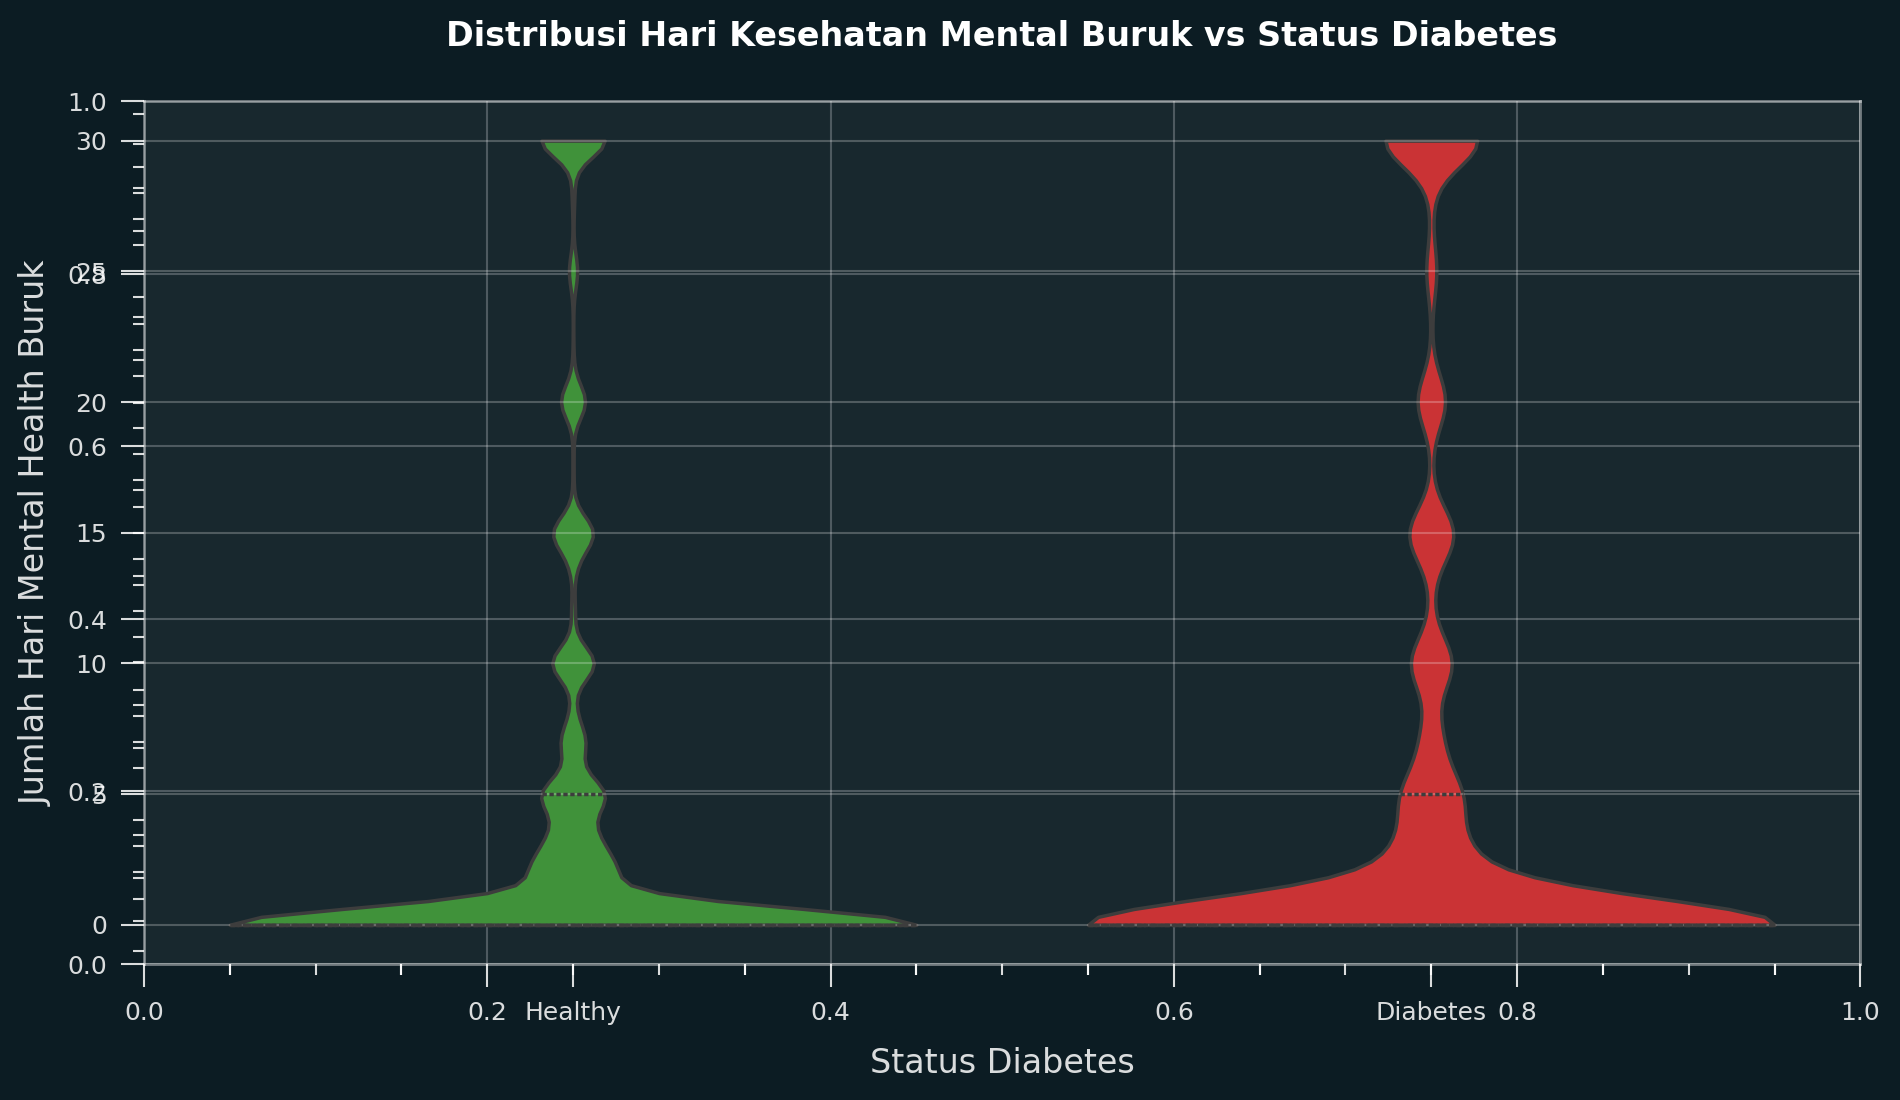

In [16]:
# 5 MENTAL HEALTH VIOLIN PLOT


fig, ax = plt.subplots(figsize=(10, 6))

# Swapped to violinplot to better visualize the heavy skew towards 0 and 30 days
sns.violinplot(
    data=df,
    x="DIABETE4",
    y="MENTHLTH",
    palette=['C1', 'C0'],
    inner="quartile",  # Shows the quartiles inside the violin
    cut=0,  # Prevents the plot from smoothing into negative numbers
    ax=ax
)

plt.title(
    "Distribusi Hari Kesehatan Mental Buruk vs Status Diabetes",
    weight="bold",
    pad=20
)

plt.xlabel("Status Diabetes")
plt.ylabel("Jumlah Hari Mental Health Buruk")

plt.tight_layout()

plt.show()


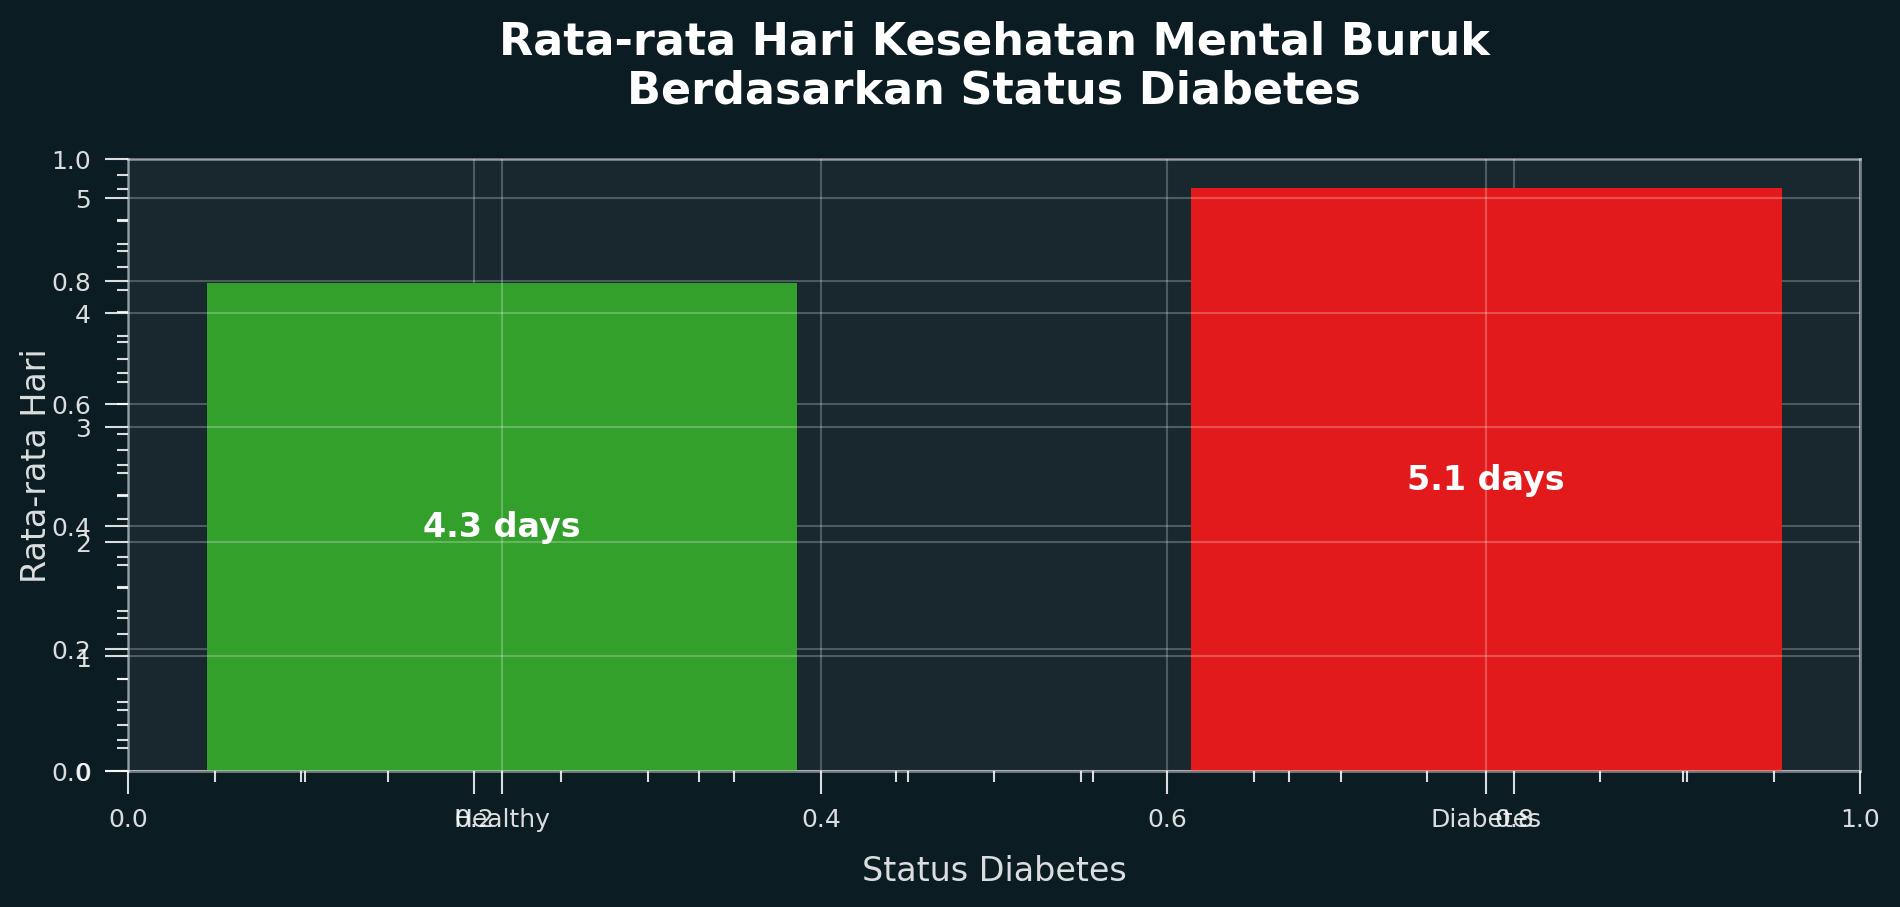

In [17]:
# MEAN MENTAL HEALTH


mental_mean = (
    df.groupby("DIABETE4")["MENTHLTH"]
    .mean()
    .reindex(["Healthy", "Diabetes"])
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    mental_mean.index,
    mental_mean.values,
    color=['C1', 'C0'],
    width=0.6
)

for bar in bars:
    h = bar.get_height()
    ax.annotate(
        f"{h:.1f} days",
        (bar.get_x() + bar.get_width() / 2, h / 2),
        ha="center",
        va="center",
        color="#FFFFFF",
        fontweight="bold",
        fontsize=12
    )

plt.title(
    "Rata-rata Hari Kesehatan Mental Buruk\nBerdasarkan Status Diabetes",
    fontsize=16,
    weight="bold",
    pad=20
)

plt.ylabel("Rata-rata Hari")
plt.xlabel("Status Diabetes")

plt.tight_layout()

plt.show()


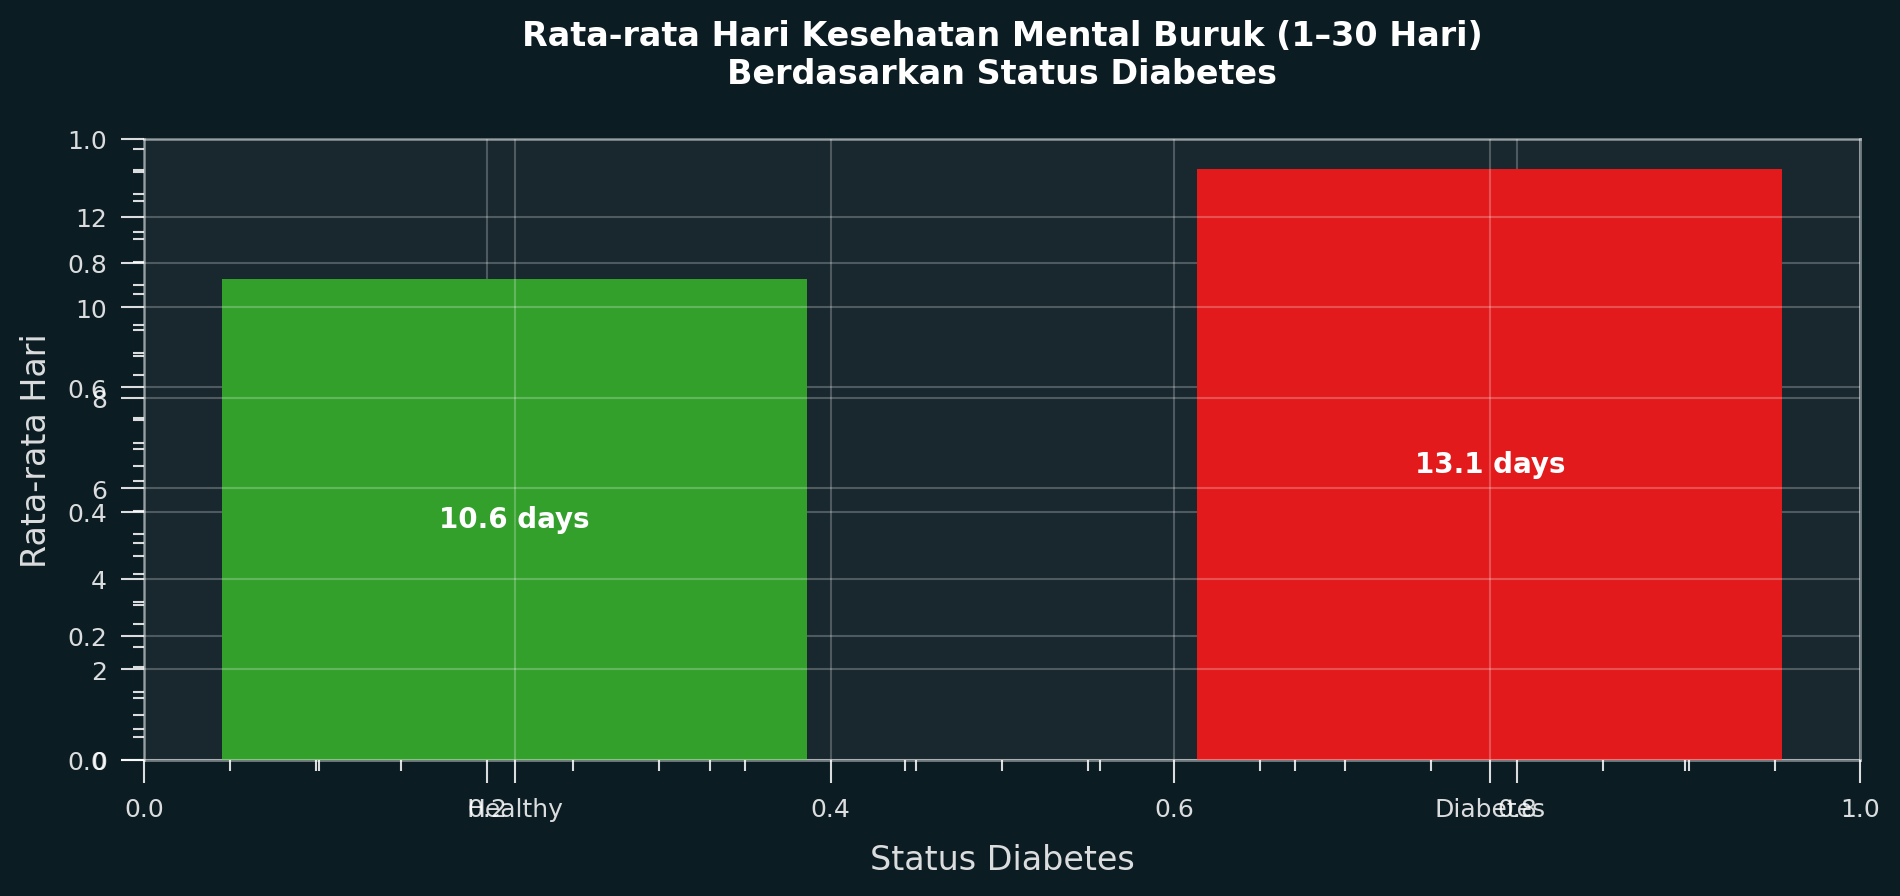

In [18]:
# MEAN MENTAL HEALTH (NONZERO)


df_mh_nonzero = df[df["MENTHLTH"] > 0]

mental_mean_nonzero = (
    df_mh_nonzero.groupby("DIABETE4")["MENTHLTH"]
    .mean()
    .reindex(["Healthy", "Diabetes"])
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    mental_mean_nonzero.index,
    mental_mean_nonzero.values,
    color=['C1', 'C0'],
    width=0.6
)

for bar in bars:
    h = bar.get_height()
    ax.annotate(
        f"{h:.1f} days",
        (bar.get_x() + bar.get_width() / 2, h / 2),
        ha="center",
        va="center",
        color="#FFFFFF",
        fontweight="bold"
    )

plt.title(
    "Rata-rata Hari Kesehatan Mental Buruk (1–30 Hari)\nBerdasarkan Status Diabetes",
    weight="bold",
    pad=20
)

plt.ylabel("Rata-rata Hari")
plt.xlabel("Status Diabetes")

plt.tight_layout()

plt.show()

Note: idk why ipynb plots looks worse